In [1]:
from src.baseline_config import build_training_config
from src.phase2.config import (
    PHASE2_CONFIDENCE_ONLY_FRAMES_DIR,
    PHASE2_CONFIDENCE_ONLY_THRESHOLD,
    PHASE2_RUNS,
)
from src.phase2.experiment import (
    curate_phase2_kinf_dataset,
    ingest_phase2_confidence_only_dataset,
    ingest_phase2_dataset,
    phase2_confidence_only_csv_path,
    phase2_confidence_only_runs,
    print_phase2_confidence_only_summary,
    print_phase2_detection_summary,
    print_phase2_failure_summary,
    print_phase2_source_summary,
    print_phase2_summary,
    print_phase2_train_summary,
    run_phase2_confidence_only_experiments,
    run_phase2_experiments,
    show_phase2_confidence_only_plots,
    show_phase2_plots,
)
from utils.metrics import print_results_metrics_summary

TRAINING_CONFIG = build_training_config(architecture="efficientnet_b0")


In [2]:
print_phase2_source_summary()

histology
Adenoma                     1578
Sessile_serrated_adenoma     725
Hyperplastic                 334
Adenocarcinoma               101
total: 2738


In [3]:
execute = False
if execute:
    ingestion_summary = ingest_phase2_dataset()
    ingestion_summary

In [4]:
curation_summary = curate_phase2_kinf_dataset()
curation_summary

{'source_csv_path': 'C:\\Users\\luis\\Documents\\TFG - Data-Centric AI\\data\\phase2\\phase2_train.csv',
 'output_csv_path': 'C:\\Users\\luis\\Documents\\TFG - Data-Centric AI\\data\\phase2\\phase2_train_kinf.csv',
 'confidence_threshold': 0.4,
 'total_rows': 2816,
 'original_rows': 2738,
 'video_rows': 78,
 'dropped_video_rows': 30}

In [5]:
print_phase2_train_summary()

histology
Adenoma                     1592
Sessile_serrated_adenoma     776
Hyperplastic                 347
Adenocarcinoma               101
total: 2816


In [6]:
print_phase2_detection_summary()

               histology  total_images  annotated_images  unannotated_images  mean_annotated_confidence
                   TOTAL          2816               117                2699                     0.5770
          Adenocarcinoma           101                 0                 101                        NaN
                 Adenoma          1592                33                1559                     0.5413
            Hyperplastic           347                16                 331                     0.5940
Sessile_serrated_adenoma           776                68                 708                     0.5904


In [7]:
run_phase2_experiments(training_config=TRAINING_CONFIG, force_train=False)

Loading model located at: C:\Users\luis\Documents\TFG - Data-Centric AI\results\EfficientNet\phase2\seed_1\best_baseline_model.pth


Loading model located at: C:\Users\luis\Documents\TFG - Data-Centric AI\results\EfficientNet\phase2\seed_2\best_baseline_model.pth
Loading model located at: C:\Users\luis\Documents\TFG - Data-Centric AI\results\EfficientNet\phase2\seed_3\best_baseline_model.pth
Loading model located at: C:\Users\luis\Documents\TFG - Data-Centric AI\results\EfficientNet\phase2\seed_4\best_baseline_model.pth


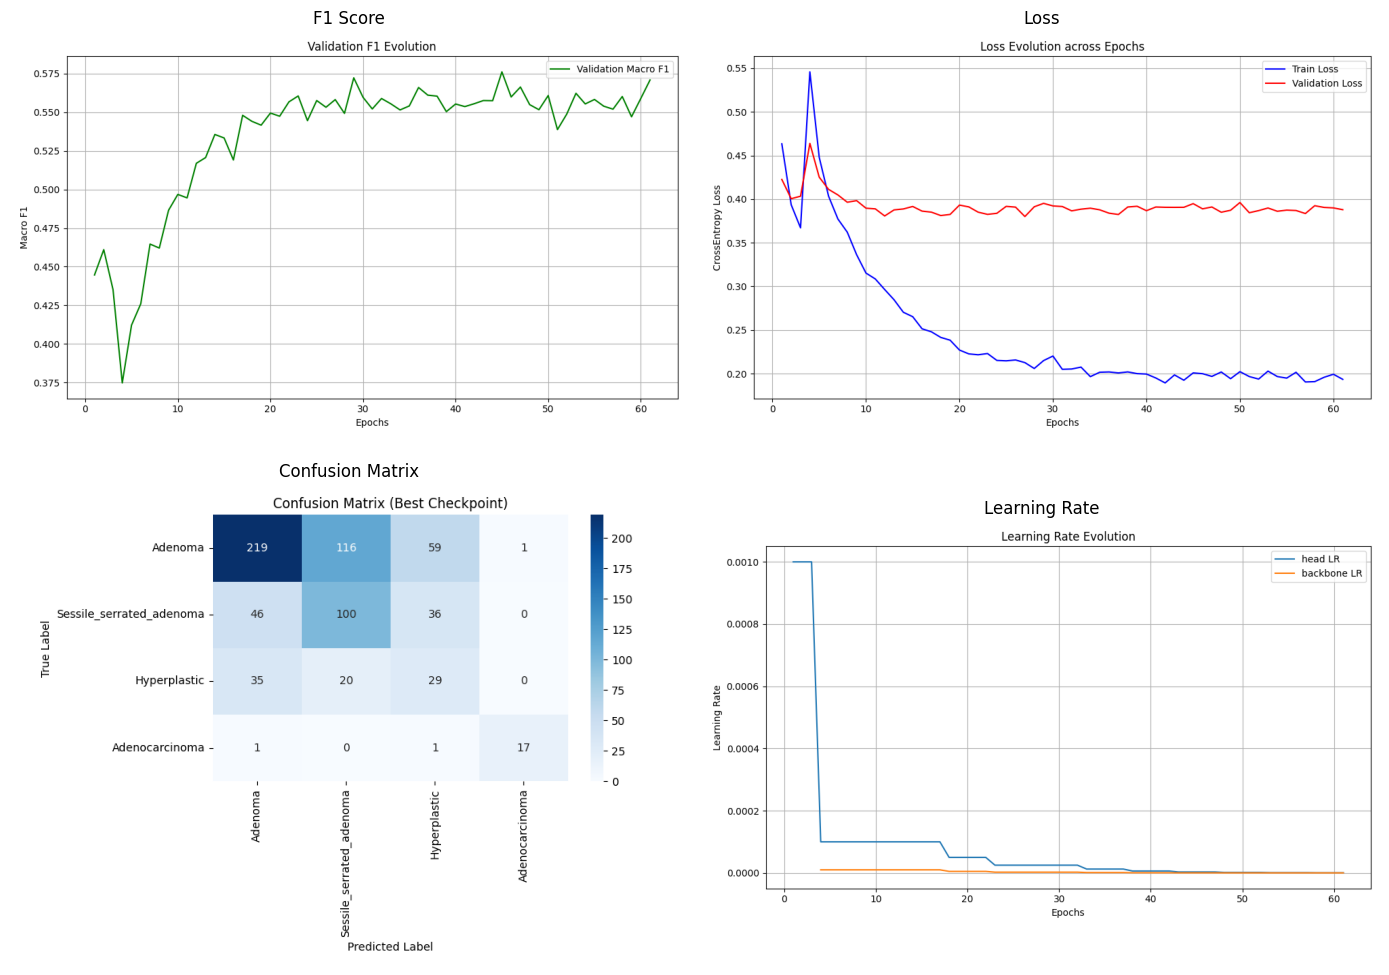

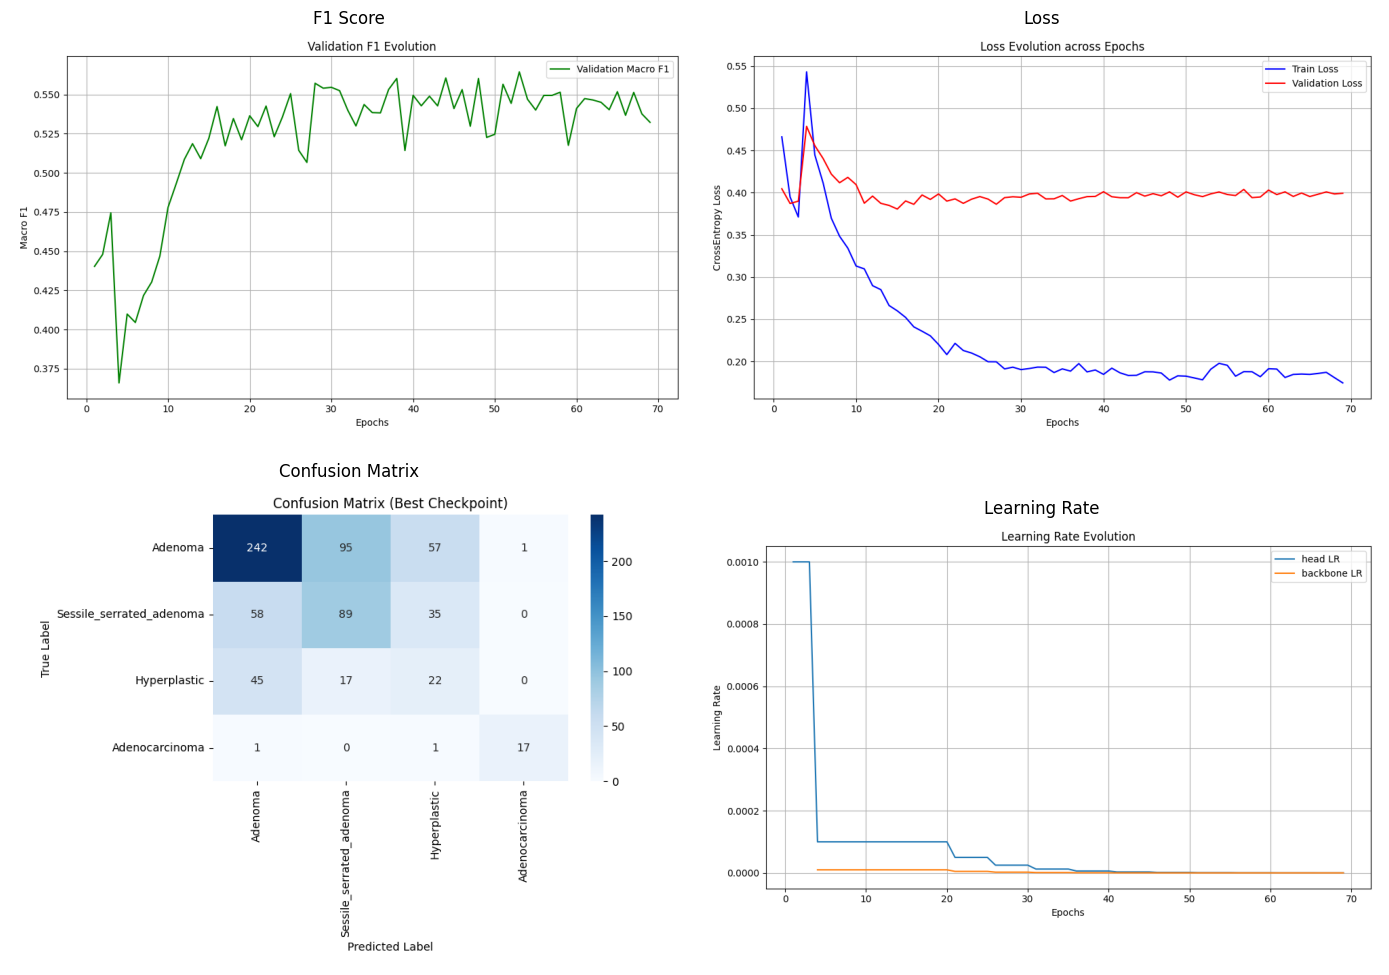

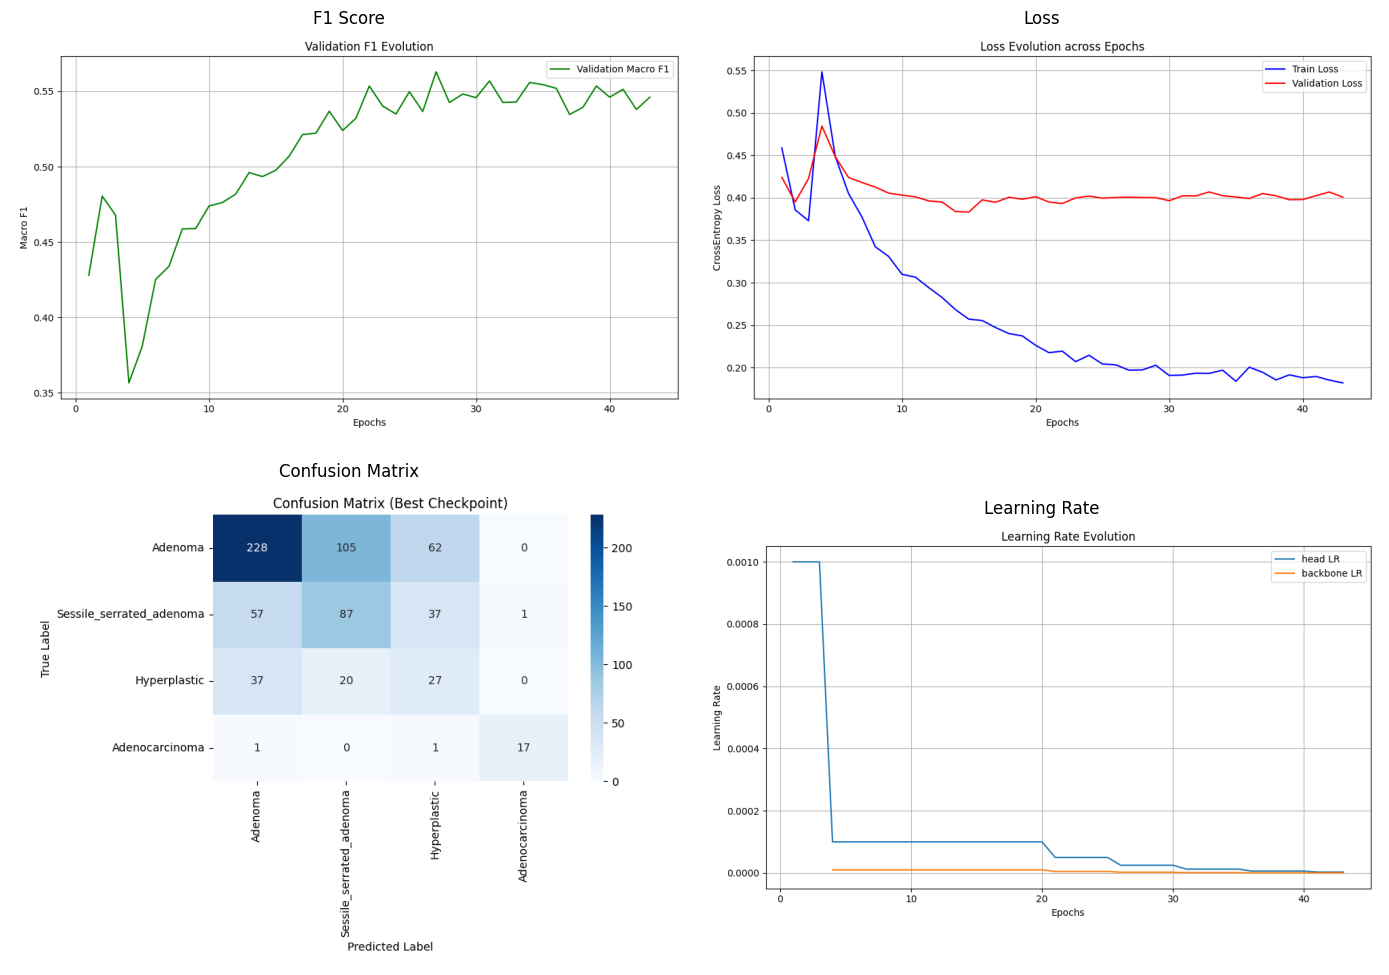

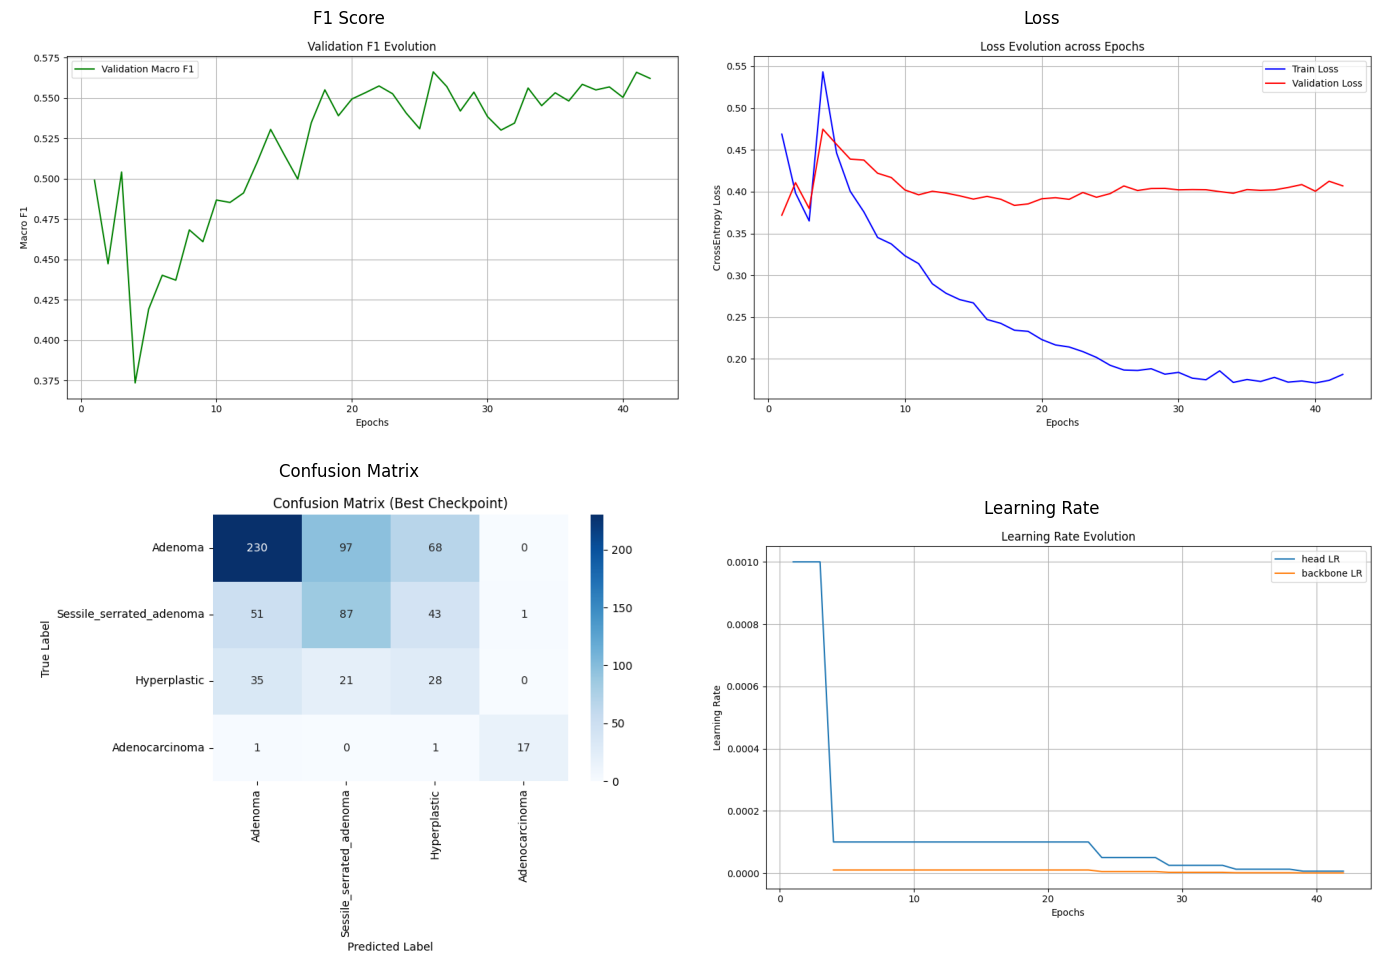

In [8]:
show_phase2_plots(training_config=TRAINING_CONFIG)

In [9]:
print_phase2_summary(training_config=TRAINING_CONFIG)

,scope,accuracy,mcc,macro_f1,precision,recall
0,general,0.5353 +/- 0.0069,0.2514 +/- 0.0122,0.5674 +/- 0.0059,0.5733 +/- 0.0062,0.5726 +/- 0.0094
1,Adenoma,0.6217 +/- 0.0060,0.2561 +/- 0.0159,0.6409 +/- 0.0107,0.7146 +/- 0.0141,0.5816 +/- 0.0240
2,Sessile_serrated_adenoma,0.6853 +/- 0.0098,0.2407 +/- 0.0195,0.4586 +/- 0.0163,0.4253 +/- 0.0133,0.4986 +/- 0.0343
3,Hyperplastic,0.7680 +/- 0.0107,0.1244 +/- 0.0263,0.2511 +/- 0.0233,0.2090 +/- 0.0177,0.3155 +/- 0.0370
4,Adenocarcinoma,0.9956 +/- 0.0000,0.9170 +/- 0.0000,0.9189 +/- 0.0000,0.9444 +/- 0.0000,0.8947 +/- 0.0000


In [10]:
print_results_metrics_summary(
    results_dirs=[run["results_dir"] for run in PHASE2_RUNS],
    validation_csv_dir="test/external_test.csv",
    validation_img_dir="test/images_cropped",
    training_config=TRAINING_CONFIG,
    random_states=[run["random_state"] for run in PHASE2_RUNS],
)

,scope,accuracy,mcc,macro_f1,precision,recall
0,general,0.4110 +/- 0.0171,0.2638 +/- 0.0154,0.3544 +/- 0.0120,0.4606 +/- 0.0040,0.4660 +/- 0.0131
1,Adenoma,0.6399 +/- 0.0125,0.2154 +/- 0.0099,0.4751 +/- 0.0126,0.4163 +/- 0.0087,0.5554 +/- 0.0420
2,Sessile_serrated_adenoma,0.7056 +/- 0.0218,0.0945 +/- 0.0101,0.0612 +/- 0.0048,0.0321 +/- 0.0026,0.6528 +/- 0.0278
3,Hyperplastic,0.6794 +/- 0.0033,0.1093 +/- 0.0181,0.2303 +/- 0.0215,0.4609 +/- 0.0195,0.1536 +/- 0.0169
4,Adenocarcinoma,0.7972 +/- 0.0134,0.5772 +/- 0.0221,0.6508 +/- 0.0404,0.9332 +/- 0.0280,0.5022 +/- 0.0550


In [4]:
confidence_ingestion_summary = ingest_phase2_confidence_only_dataset(
    confidence_threshold=PHASE2_CONFIDENCE_ONLY_THRESHOLD,
    frames_dir=PHASE2_CONFIDENCE_ONLY_FRAMES_DIR,
)
confidence_ingestion_summary

Max candidates per histology: {'Adenoma': 15, 'Sessile_serrated_adenoma': 15, 'Hyperplastic': 15, 'Adenocarcinoma': 15}
Histology augmentation summary:
               histology  current_samples  max_added_per_sample  max_added_samples  estimated_final_samples
                 Adenoma             1578                    15              23670                    25248
Sessile_serrated_adenoma              725                    15              10875                    11600
            Hyperplastic              334                    15               5010                     5344
          Adenocarcinoma              101                    15               1515                     1616
Estimated totals: current_samples=2738, max_added_samples=41070, estimated_final_samples=43808


Reintentando videos: 100%|██████████| 5/5 [00:17<00:00,  3.52s/video, pendientes=0 fallidos=4 anadidas[Adenoma:6735 SSA:2322 Hyperplastic:1087 Adenocarcinoma:414]]


{'videos_processed_first_pass': 4,
 'videos_recovered_second_pass': 1,
 'videos_still_failed': 4,
 'videos_done': 424,
 'videos_pending': 0,
 'ingestion_complete': False,
 'rows_output': 13296,
 'output_csv_path': 'C:\\Users\\luis\\Documents\\TFG - Data-Centric AI\\data\\phase2\\phase2_train_conf060.csv',
 'state_json_path': 'C:\\Users\\luis\\Documents\\TFG - Data-Centric AI\\data\\phase2\\phase2_train_conf060.json',
 'confidence_threshold': 0.6,
 'use_histology_candidate_limits': False,
 'frames_dir': 'C:\\Users\\luis\\Documents\\TFG - Data-Centric AI\\data\\phase2\\frames_confidence_only'}

In [5]:
CONFIDENCE_ONLY_TRAIN_CSV = phase2_confidence_only_csv_path(
    PHASE2_CONFIDENCE_ONLY_THRESHOLD
)
print_phase2_failure_summary(output_csv_path=CONFIDENCE_ONLY_TRAIN_CSV)


,video_key,status,error_type,message,traceback_tail
0,4101414::20241213_102820_R2_34b16ba5d8336515.mp4,failed,FileNotFoundError,Could not open video: c:\Users\luis\Documents\...,"File ""c:\Users\luis\Documents\TFG - Data-Cen..."
1,4899931::20241213_114956_R6_1e85f910cd7832f5.mp4,failed,FileNotFoundError,Could not open video: c:\Users\luis\Documents\...,"File ""c:\Users\luis\Documents\TFG - Data-Cen..."
2,70472575::20241213_133837_R6_ca03b1e440d5b383.mp4,failed,RuntimeError,download failed,"Traceback (most recent call last):\n File ""c:..."
3,70612836::20241213_151536_R4_51a2091b8a5366be.mp4,failed,FileNotFoundError,Could not open video: c:\Users\luis\Documents\...,"File ""c:\Users\luis\Documents\TFG - Data-Cen..."


In [6]:
print_phase2_train_summary(train_csv=CONFIDENCE_ONLY_TRAIN_CSV)


histology
Adenoma                     8313
Sessile_serrated_adenoma    3047
Hyperplastic                1421
Adenocarcinoma               515
total: 13296


In [7]:
print_phase2_detection_summary(train_csv=CONFIDENCE_ONLY_TRAIN_CSV)


               histology  total_images  annotated_images  unannotated_images  mean_annotated_confidence
                   TOTAL         13296             12494                 802                     0.7240
          Adenocarcinoma           515               496                  19                     0.6878
                 Adenoma          8313              7867                 446                     0.7414
            Hyperplastic          1421              1312                 109                     0.6921
Sessile_serrated_adenoma          3047              2819                 228                     0.6969


In [9]:
run_phase2_confidence_only_experiments(
    training_config=TRAINING_CONFIG,
    force_train=False,
    confidence_threshold=PHASE2_CONFIDENCE_ONLY_THRESHOLD,
    train_images_dir=PHASE2_CONFIDENCE_ONLY_FRAMES_DIR,
)


Loss weights: {'Adenoma': 0.297, 'Sessile_serrated_adenoma': 0.5995, 'Hyperplastic': 1.0226, 'Adenocarcinoma': 2.0809}
Initiating training phase. Saving results to: C:\Users\luis\Documents\TFG - Data-Centric AI\results\EfficientNet\phase2\conf060\seed_1


Training Progress:  37%|███▋      | 37/100 [42:16<1:11:58, 68.55s/epoch, Stage=full_network, Train Loss=0.0820, Val Loss=0.3406, Val Macro F1=0.5789, Selection Score=-0.5789, Best Epoch=22, LR=3.1e-07/3.1e-06]       


Early stopping triggered after 16 epochs without improving macro_f1.
Optimization sequence completed with seed 42. Selected checkpoint macro-F1: 0.5984 with validation loss 0.3197 and validation score -0.5984 at epoch 22.
Artifacts successfully written to 'C:\Users\luis\Documents\TFG - Data-Centric AI\results\EfficientNet\phase2\conf060\seed_1'.
Loss weights: {'Adenoma': 0.297, 'Sessile_serrated_adenoma': 0.5995, 'Hyperplastic': 1.0226, 'Adenocarcinoma': 2.0809}
Initiating training phase. Saving results to: C:\Users\luis\Documents\TFG - Data-Centric AI\results\EfficientNet\phase2\conf060\seed_2


Training Progress:  40%|████      | 40/100 [45:26<1:08:10, 68.17s/epoch, Stage=full_network, Train Loss=0.0957, Val Loss=0.3244, Val Macro F1=0.5551, Selection Score=-0.5551, Best Epoch=25, LR=1.6e-07/1.6e-06]       


Early stopping triggered after 16 epochs without improving macro_f1.
Optimization sequence completed with seed 123. Selected checkpoint macro-F1: 0.5776 with validation loss 0.3196 and validation score -0.5776 at epoch 25.
Artifacts successfully written to 'C:\Users\luis\Documents\TFG - Data-Centric AI\results\EfficientNet\phase2\conf060\seed_2'.
Loss weights: {'Adenoma': 0.297, 'Sessile_serrated_adenoma': 0.5995, 'Hyperplastic': 1.0226, 'Adenocarcinoma': 2.0809}
Initiating training phase. Saving results to: C:\Users\luis\Documents\TFG - Data-Centric AI\results\EfficientNet\phase2\conf060\seed_3


Training Progress:  40%|████      | 40/100 [45:21<1:08:01, 68.03s/epoch, Stage=full_network, Train Loss=0.1055, Val Loss=0.3253, Val Macro F1=0.5619, Selection Score=-0.5619, Best Epoch=25, LR=1.6e-07/1.6e-06]       


Early stopping triggered after 16 epochs without improving macro_f1.
Optimization sequence completed with seed 456. Selected checkpoint macro-F1: 0.5787 with validation loss 0.3156 and validation score -0.5787 at epoch 25.
Artifacts successfully written to 'C:\Users\luis\Documents\TFG - Data-Centric AI\results\EfficientNet\phase2\conf060\seed_3'.
Loss weights: {'Adenoma': 0.297, 'Sessile_serrated_adenoma': 0.5995, 'Hyperplastic': 1.0226, 'Adenocarcinoma': 2.0809}
Initiating training phase. Saving results to: C:\Users\luis\Documents\TFG - Data-Centric AI\results\EfficientNet\phase2\conf060\seed_4


Training Progress:  68%|██████▊   | 68/100 [1:16:24<35:57, 67.42s/epoch, Stage=full_network, Train Loss=0.0991, Val Loss=0.3327, Val Macro F1=0.5708, Selection Score=-0.5708, Best Epoch=53, LR=1.0e-07/1.0e-07]       


Early stopping triggered after 16 epochs without improving macro_f1.
Optimization sequence completed with seed 789. Selected checkpoint macro-F1: 0.5908 with validation loss 0.3368 and validation score -0.5908 at epoch 53.
Artifacts successfully written to 'C:\Users\luis\Documents\TFG - Data-Centric AI\results\EfficientNet\phase2\conf060\seed_4'.


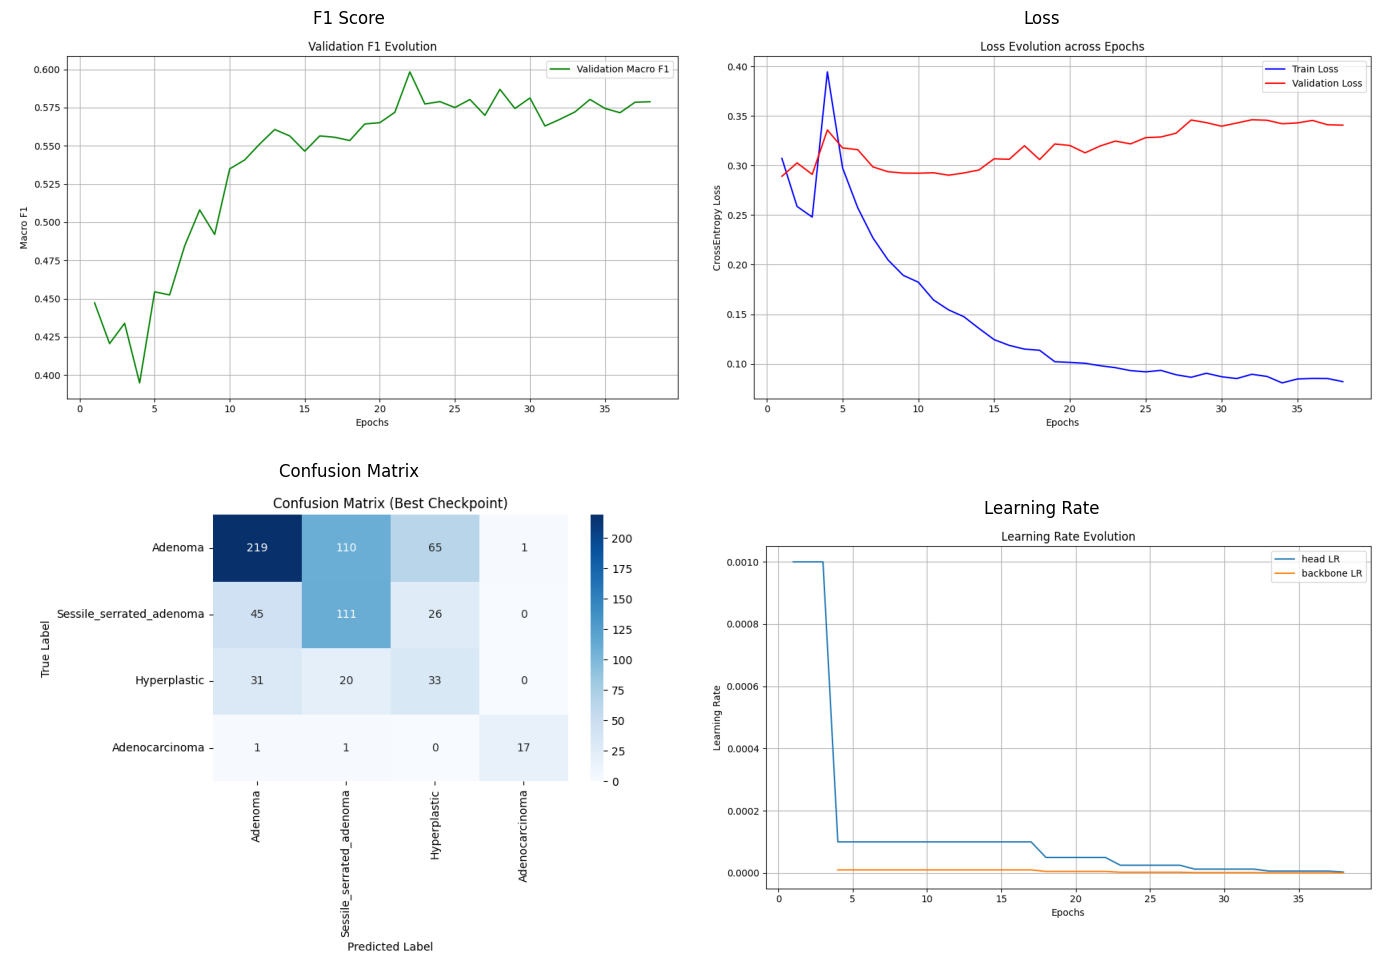

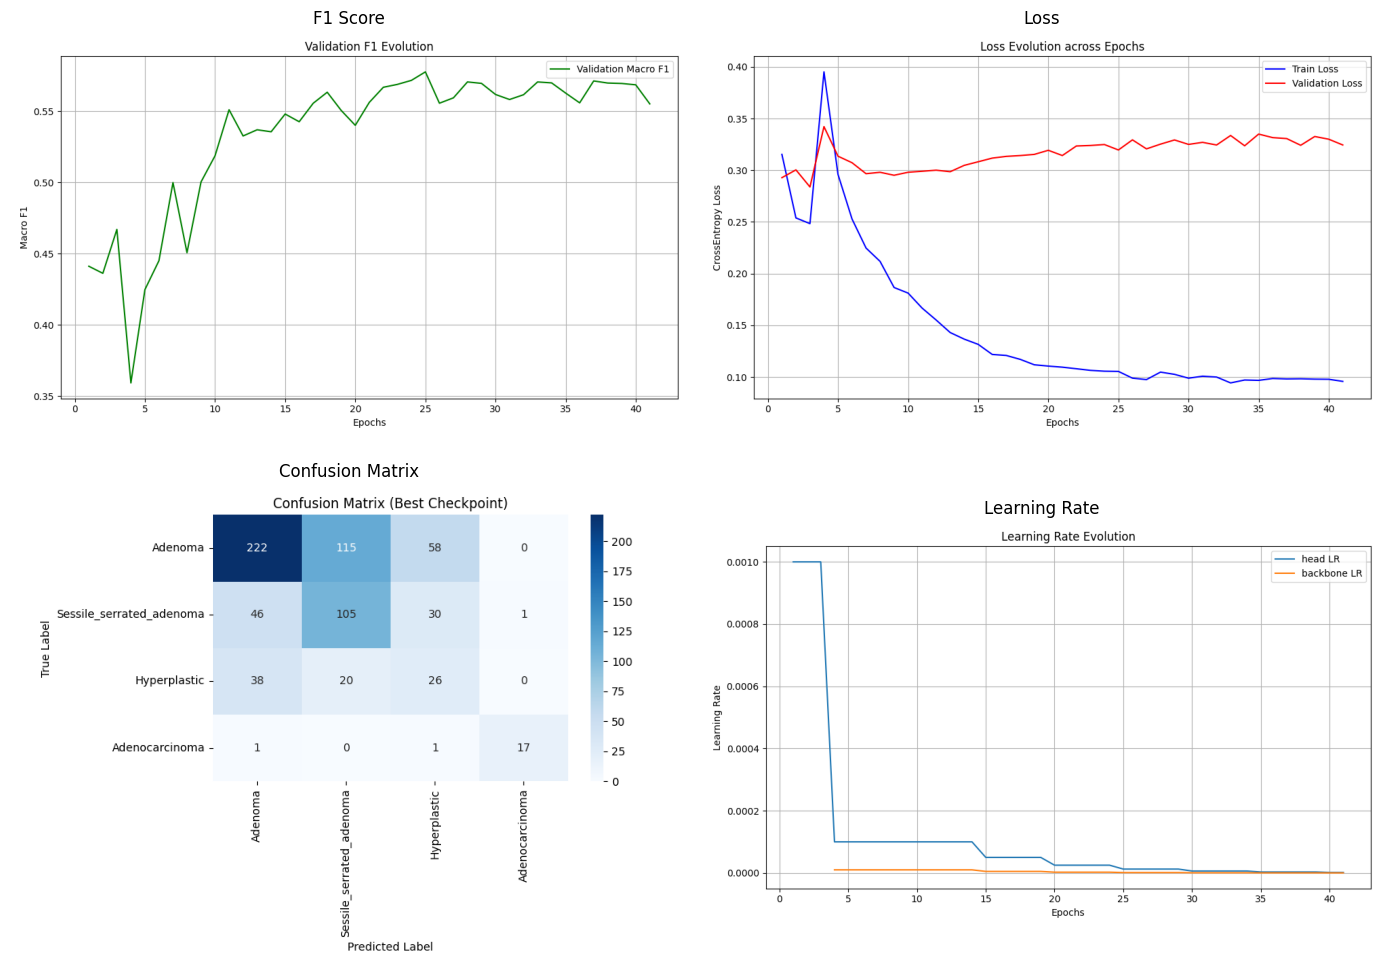

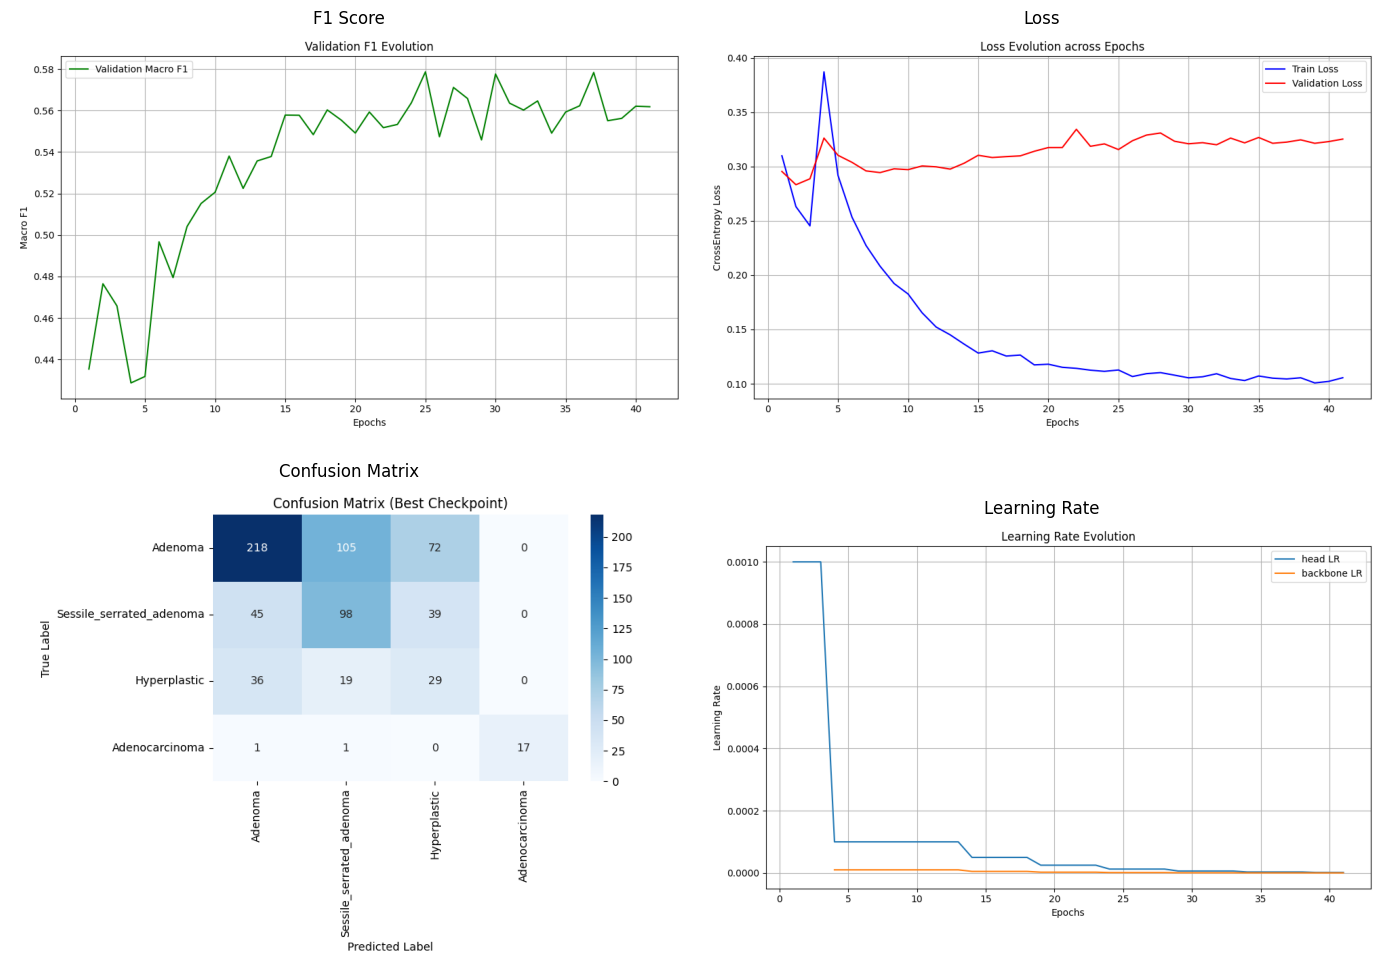

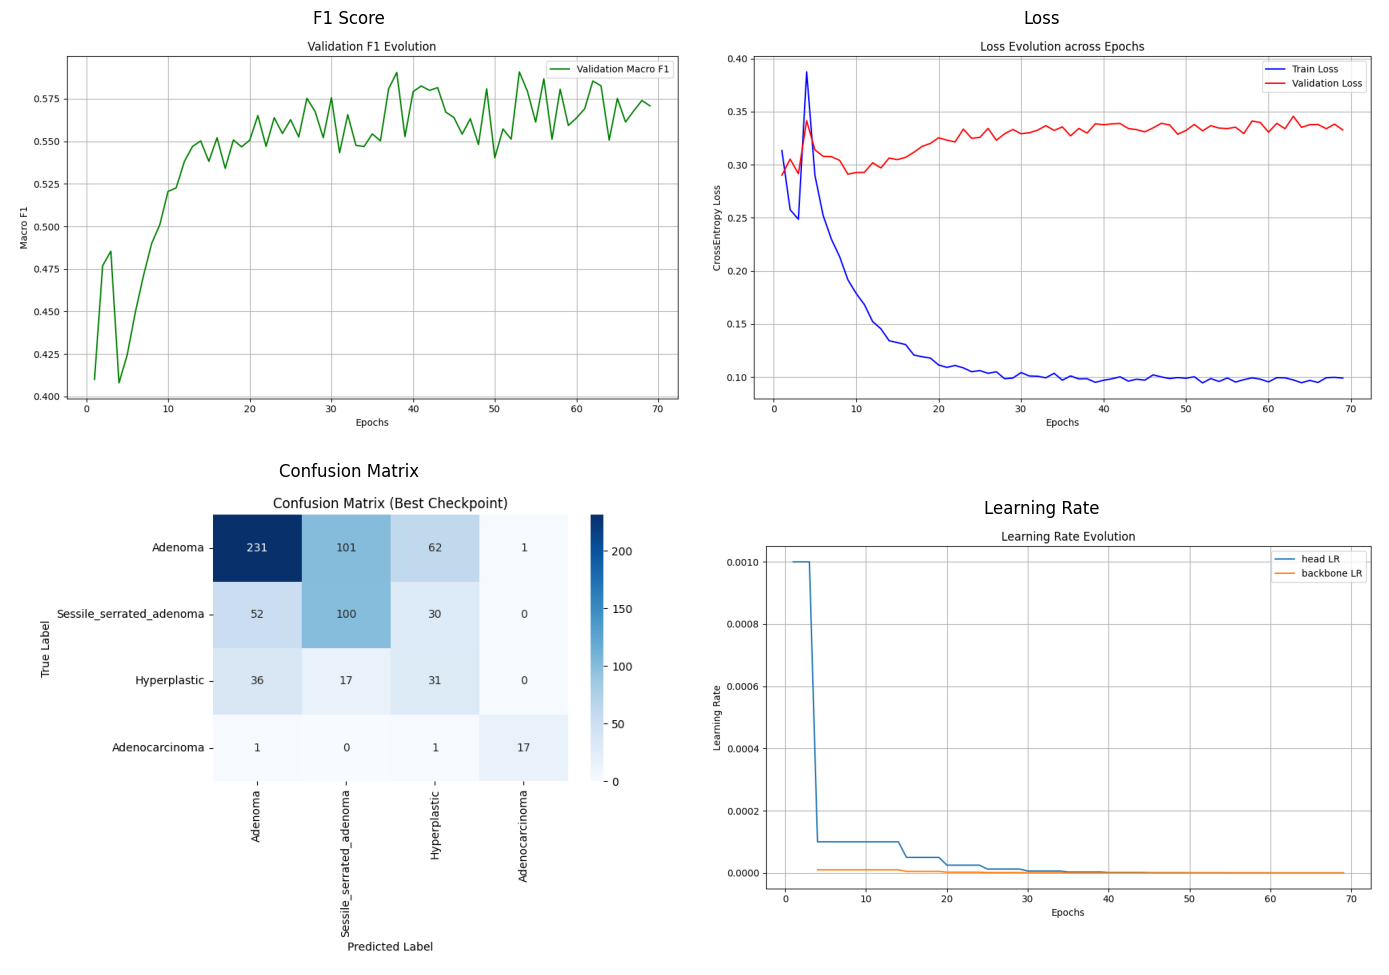

In [10]:
show_phase2_confidence_only_plots(
    training_config=TRAINING_CONFIG,
    confidence_threshold=PHASE2_CONFIDENCE_ONLY_THRESHOLD,
)


In [11]:
print_phase2_confidence_only_summary(
    training_config=TRAINING_CONFIG,
    confidence_threshold=PHASE2_CONFIDENCE_ONLY_THRESHOLD,
)


,scope,accuracy,mcc,macro_f1,precision,recall
0,general,0.5482 +/- 0.0124,0.2829 +/- 0.0186,0.5864 +/- 0.0100,0.5930 +/- 0.0080,0.5952 +/- 0.0139
1,Adenoma,0.6239 +/- 0.0047,0.2691 +/- 0.0098,0.6350 +/- 0.0080,0.7279 +/- 0.0082,0.5633 +/- 0.0150
2,Sessile_serrated_adenoma,0.6974 +/- 0.0084,0.2929 +/- 0.0212,0.5013 +/- 0.0165,0.4486 +/- 0.0117,0.5687 +/- 0.0319
3,Hyperplastic,0.7790 +/- 0.0158,0.1640 +/- 0.0351,0.2839 +/- 0.0286,0.2373 +/- 0.0260,0.3542 +/- 0.0355
4,Adenocarcinoma,0.9960 +/- 0.0007,0.9239 +/- 0.0137,0.9253 +/- 0.0128,0.9583 +/- 0.0278,0.8947 +/- 0.0000


In [12]:
CONFIDENCE_ONLY_RUNS = phase2_confidence_only_runs(
    PHASE2_CONFIDENCE_ONLY_THRESHOLD
)
print_results_metrics_summary(
    results_dirs=[run["results_dir"] for run in CONFIDENCE_ONLY_RUNS],
    validation_csv_dir="test/external_test.csv",
    validation_img_dir="test/images_cropped",
    training_config=TRAINING_CONFIG,
    random_states=[run["random_state"] for run in CONFIDENCE_ONLY_RUNS],
)


,scope,accuracy,mcc,macro_f1,precision,recall
0,general,0.4147 +/- 0.0037,0.2653 +/- 0.0048,0.3522 +/- 0.0026,0.4481 +/- 0.0088,0.4843 +/- 0.0219
1,Adenoma,0.6372 +/- 0.0142,0.2159 +/- 0.0122,0.4777 +/- 0.0060,0.4147 +/- 0.0121,0.5644 +/- 0.0232
2,Sessile_serrated_adenoma,0.7160 +/- 0.0217,0.1164 +/- 0.0292,0.0698 +/- 0.0119,0.0367 +/- 0.0064,0.7222 +/- 0.0907
3,Hyperplastic,0.6714 +/- 0.0068,0.0705 +/- 0.0264,0.1904 +/- 0.0225,0.4144 +/- 0.0375,0.1237 +/- 0.0160
4,Adenocarcinoma,0.8048 +/- 0.0072,0.5913 +/- 0.0129,0.6711 +/- 0.0208,0.9266 +/- 0.0222,0.5269 +/- 0.0302
